In [ ]:
# This notebook compares results of CB-Exp vs fixed depth options across the results of runs of notebooks: 
#           ../run_notebooks/01_catboost-dw-comparison.ipynb            ->      ../results/01_benchmark_results_depthwise.csv
#      and
#           ../run_notebooks/02_catboost-symmtree-comparison.ipynb      ->      ../results/02_benchmark_results_symmtree.csv


 DEPTHWISE
  Complete datasets : 34
  Seeds per model   : 15

 SUMMARY TABLE  [Depthwise]
                Mean Improvability     Std  Improvability     WR > 50% datasets      Mean WR               
Comparison                                                                                                 
CB-Exp vs CB-D6                +0.268%                 0.740%                23.0/34                  68.2%
CB-D9  vs CB-D6                +0.079%                 1.025%                16.0/34                  49.4%
CB-Exp vs CB-D9                +0.194%                 0.645%                23.0/34                  64.1%

Figure 1 — Improvability  [Depthwise]...
✓ Saved: fig_improvability_depthwise.pdf


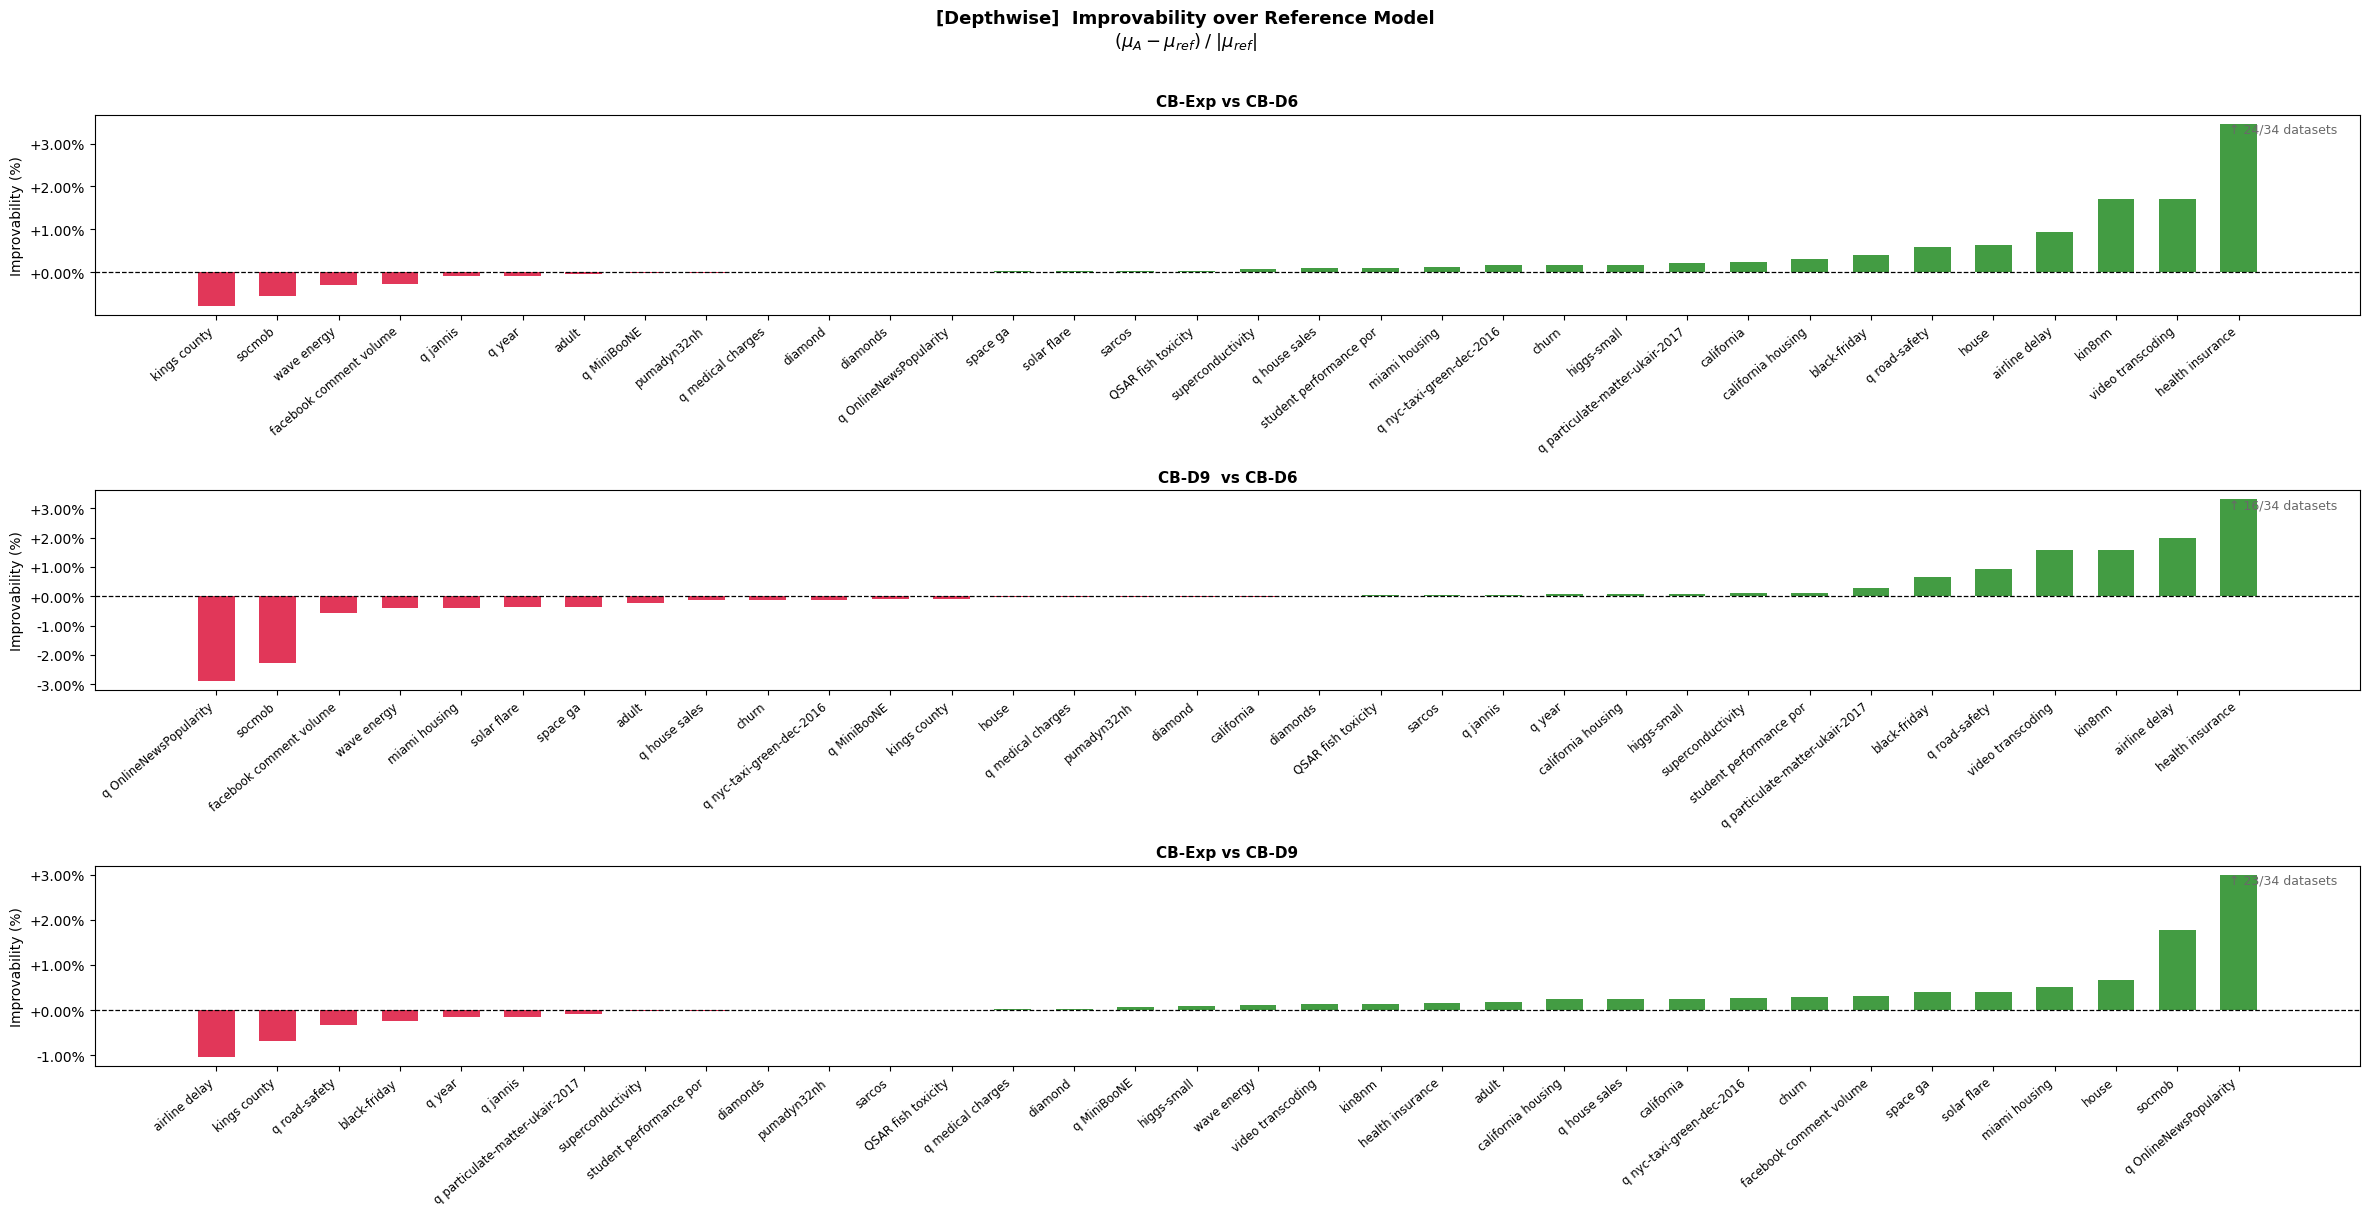

Figure 2 — Win-Rate  [Depthwise]...
✓ Saved: fig_winrate_depthwise.pdf


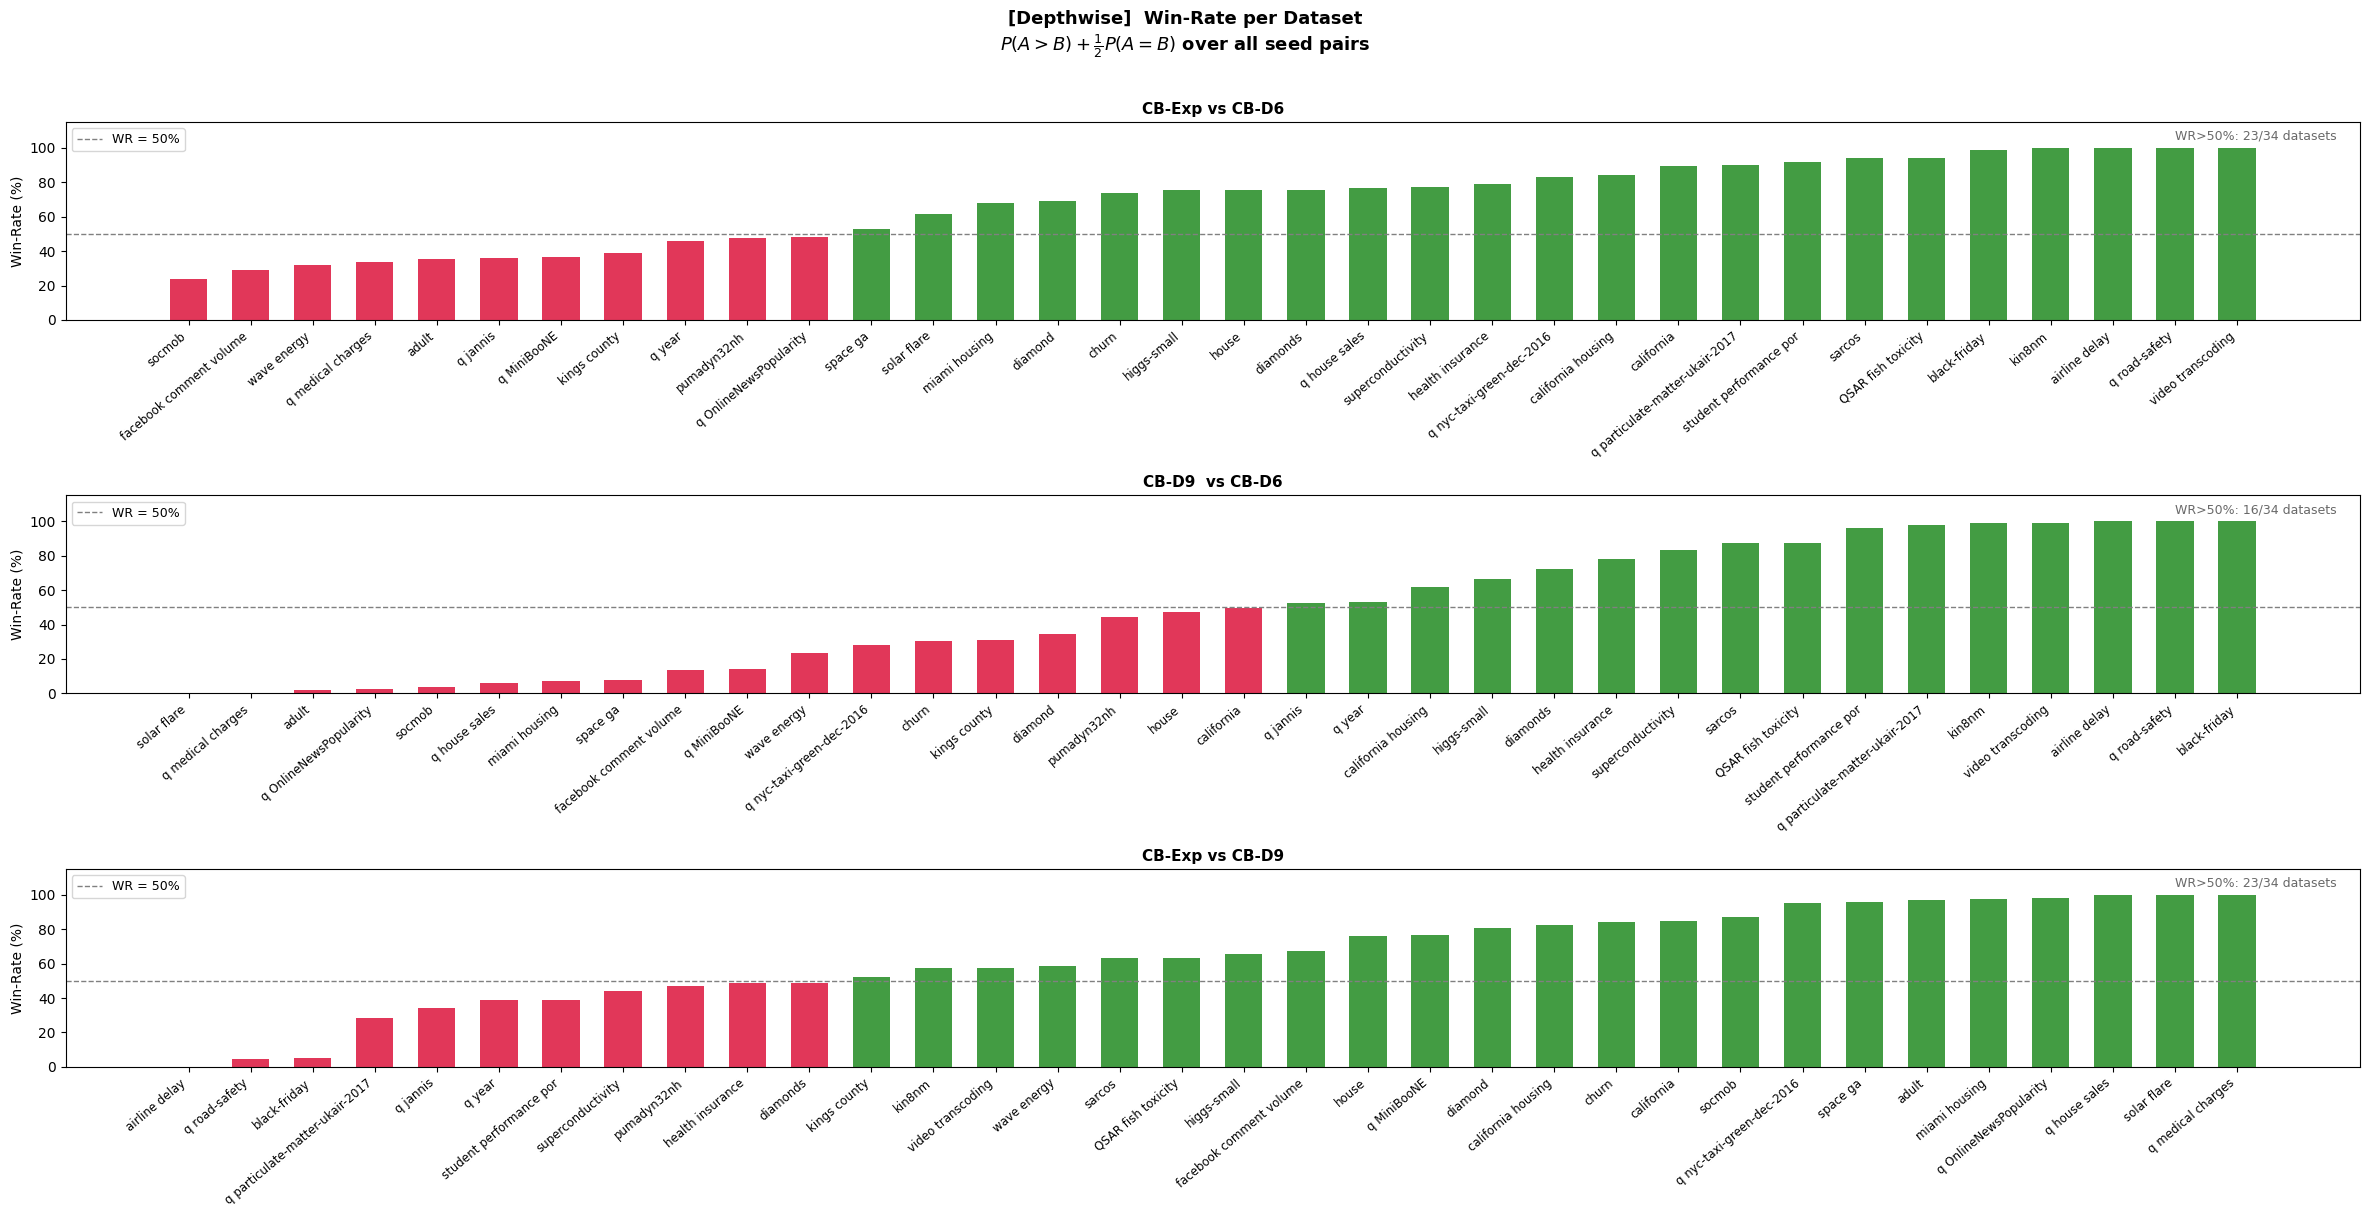

Figure 3 — 3-Way Ranking Heatmap  [Depthwise]...
✓ Saved: fig_ranking_heatmap_depthwise.pdf


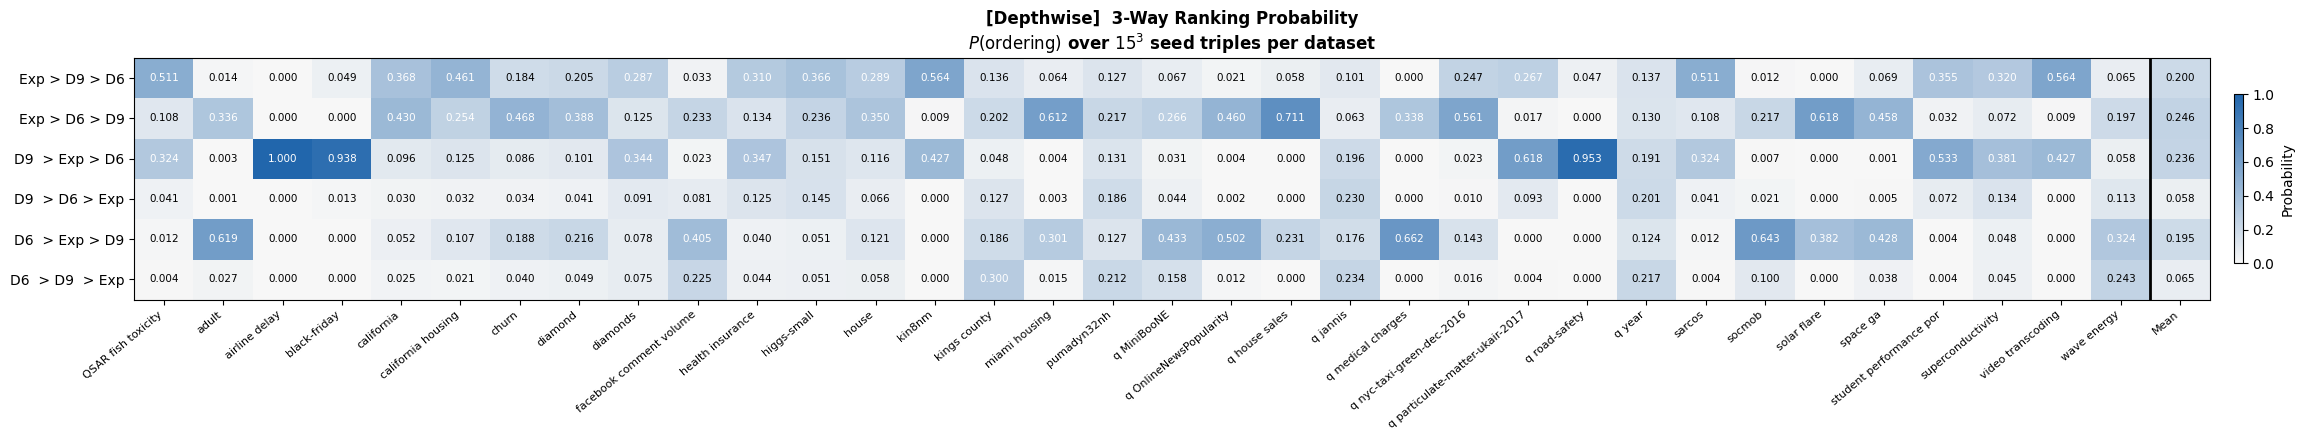

Figure 4 — Training Time Ratio  [Depthwise]...
✓ Saved: fig_time_ratio_depthwise.pdf


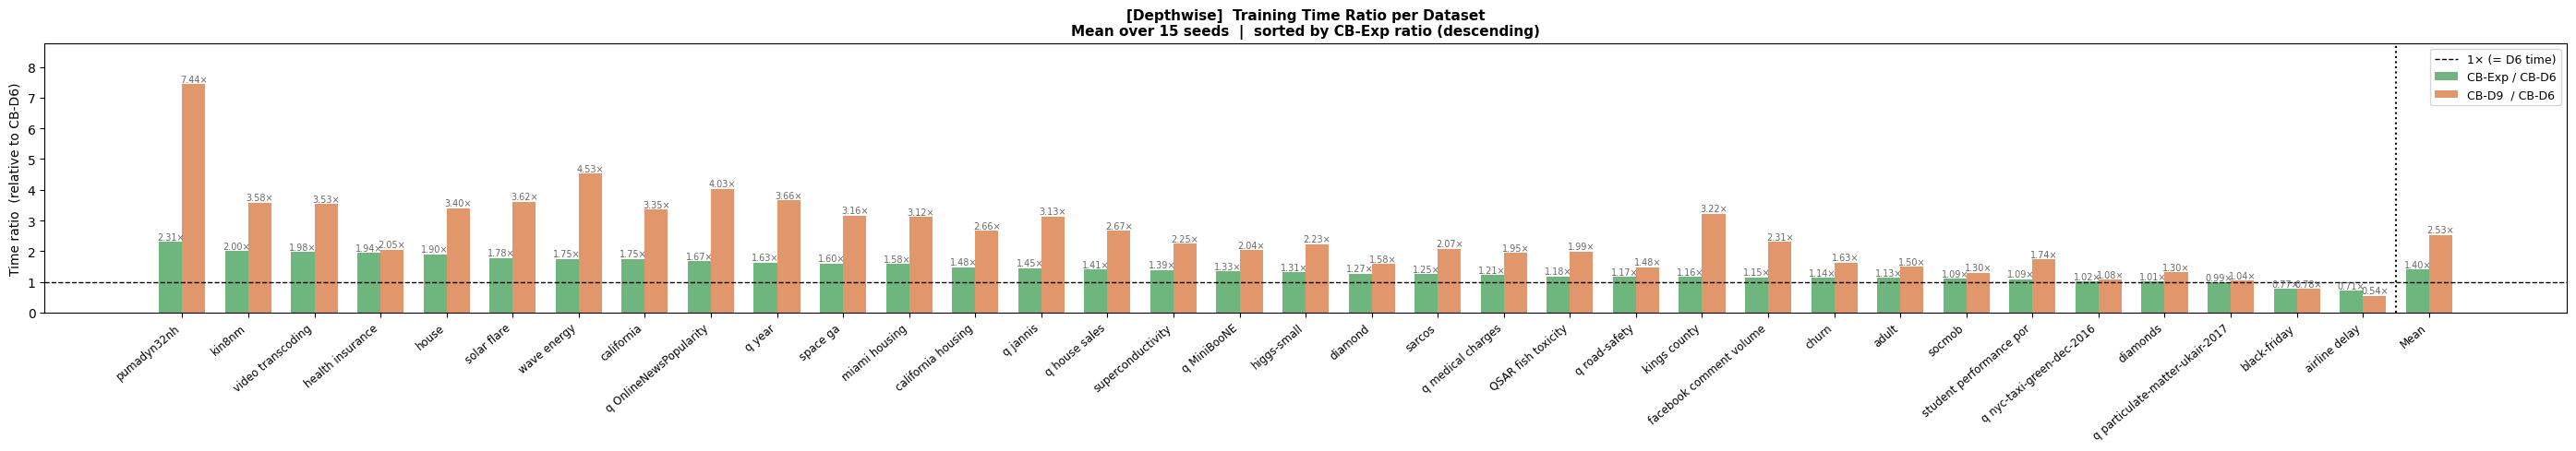

  Mean time ratio  CB-Exp / CB-D6 : 1.399×  (±0.370)
  Mean time ratio  CB-D9  / CB-D6 : 2.529×  (±1.310)

 SYMMETRICTREE
  Complete datasets : 34
  Seeds per model   : 15

 SUMMARY TABLE  [SymmetricTree]
                Mean Improvability     Std  Improvability     WR > 50% datasets      Mean WR               
Comparison                                                                                                 
CB-Exp vs CB-D6                +0.123%                 0.298%                25.0/34                  61.8%
CB-D9  vs CB-D6                +0.376%                 1.422%                19.0/34                  55.8%
CB-Exp vs CB-D9                -0.235%                 1.165%                17.0/34                  48.4%

Figure 1 — Improvability  [SymmetricTree]...
✓ Saved: fig_improvability_symmetrictree.pdf


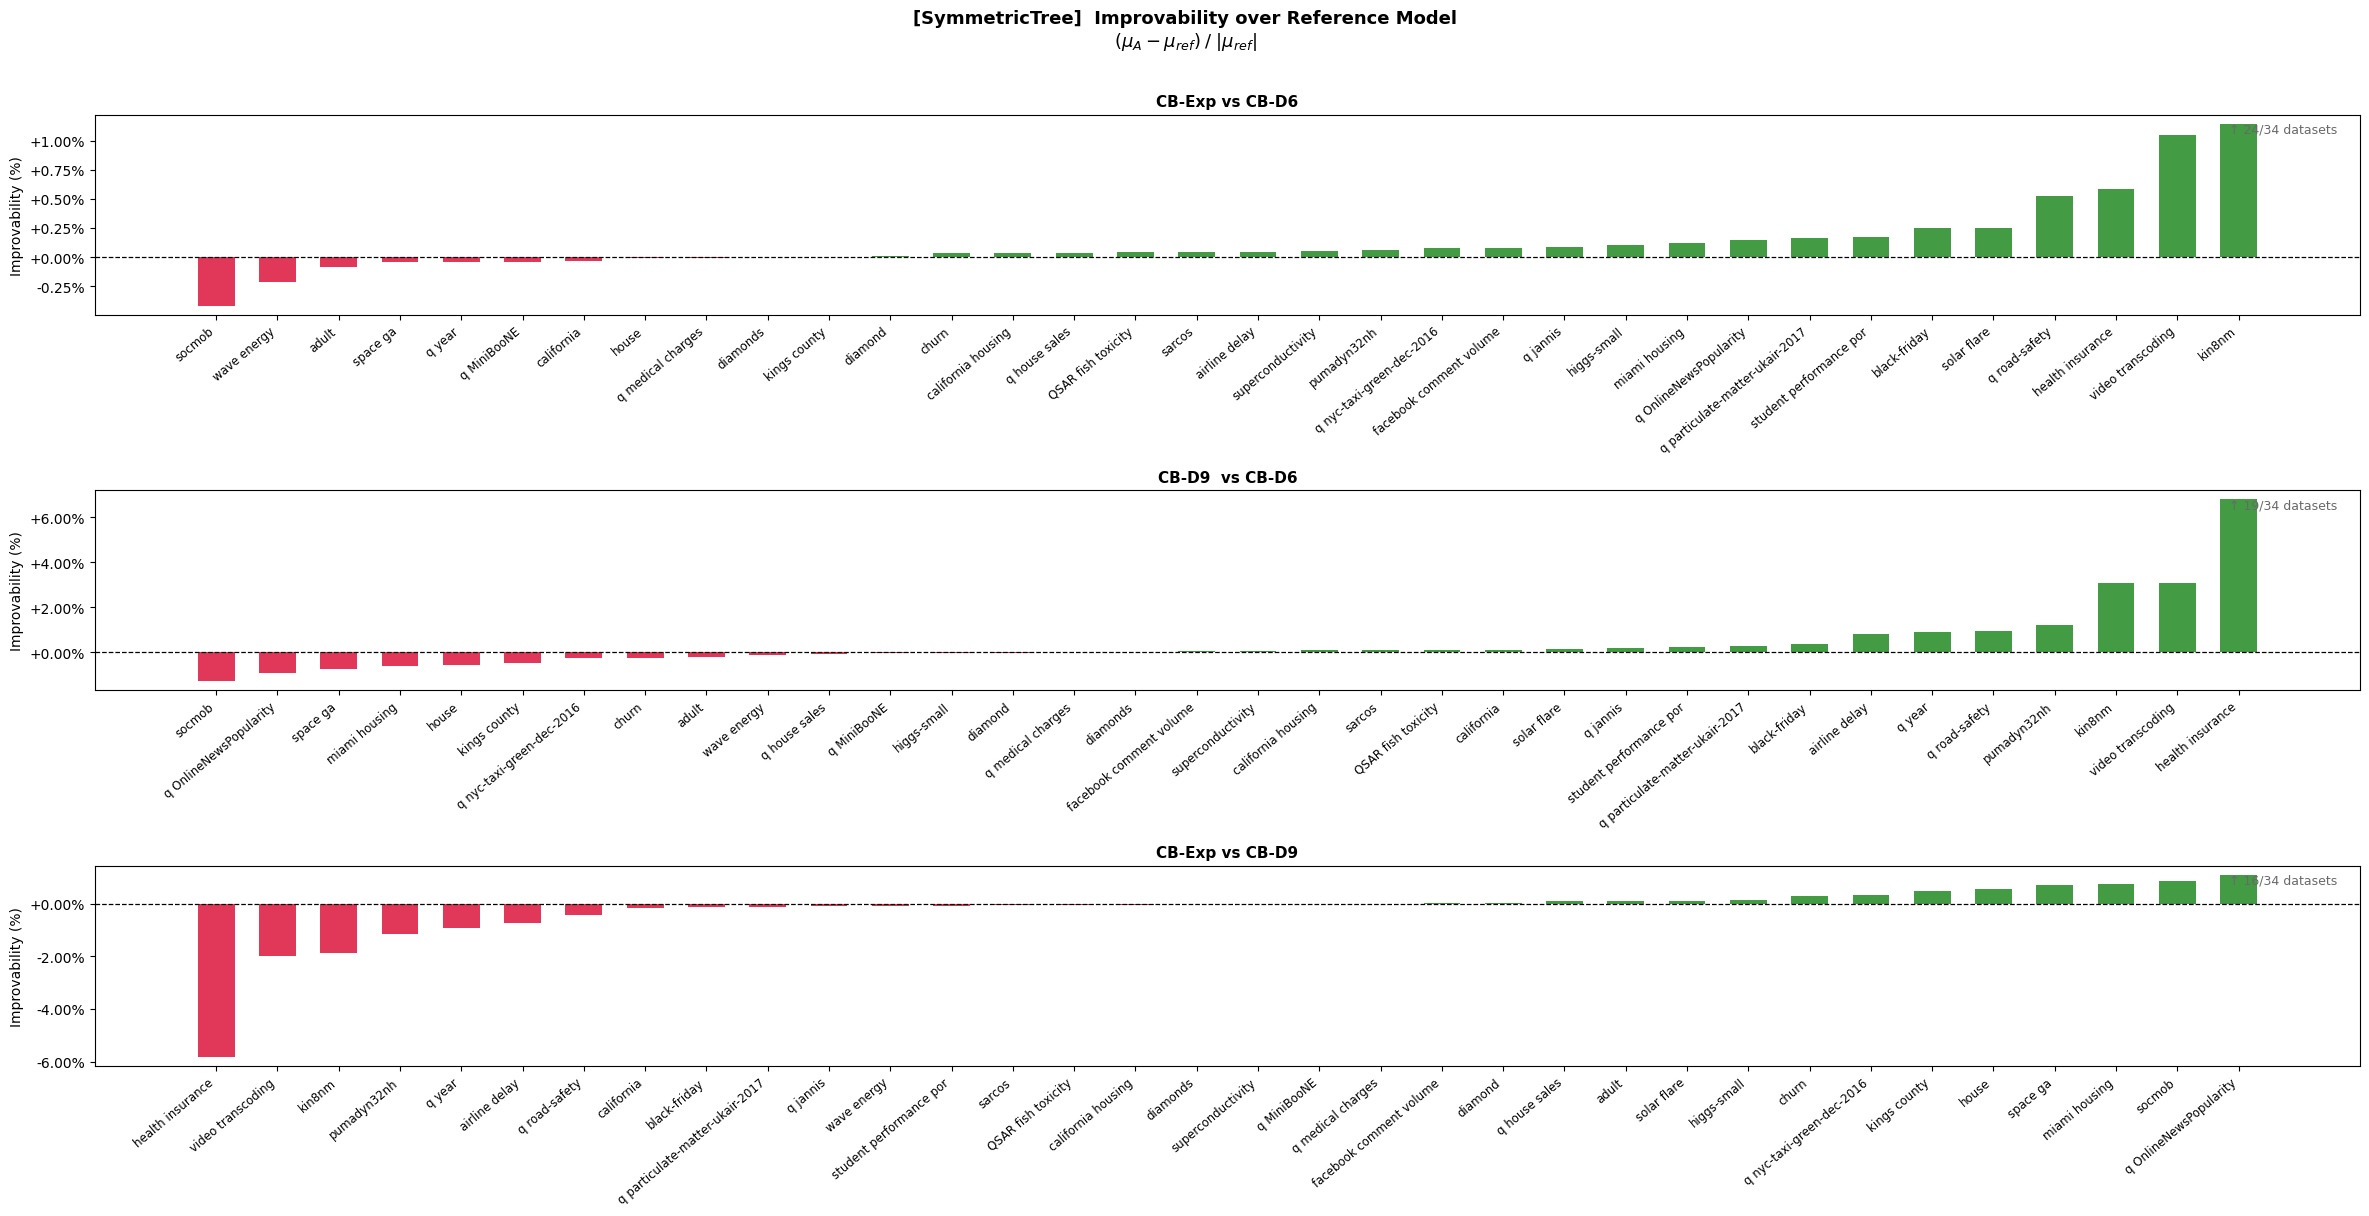

Figure 2 — Win-Rate  [SymmetricTree]...
✓ Saved: fig_winrate_symmetrictree.pdf


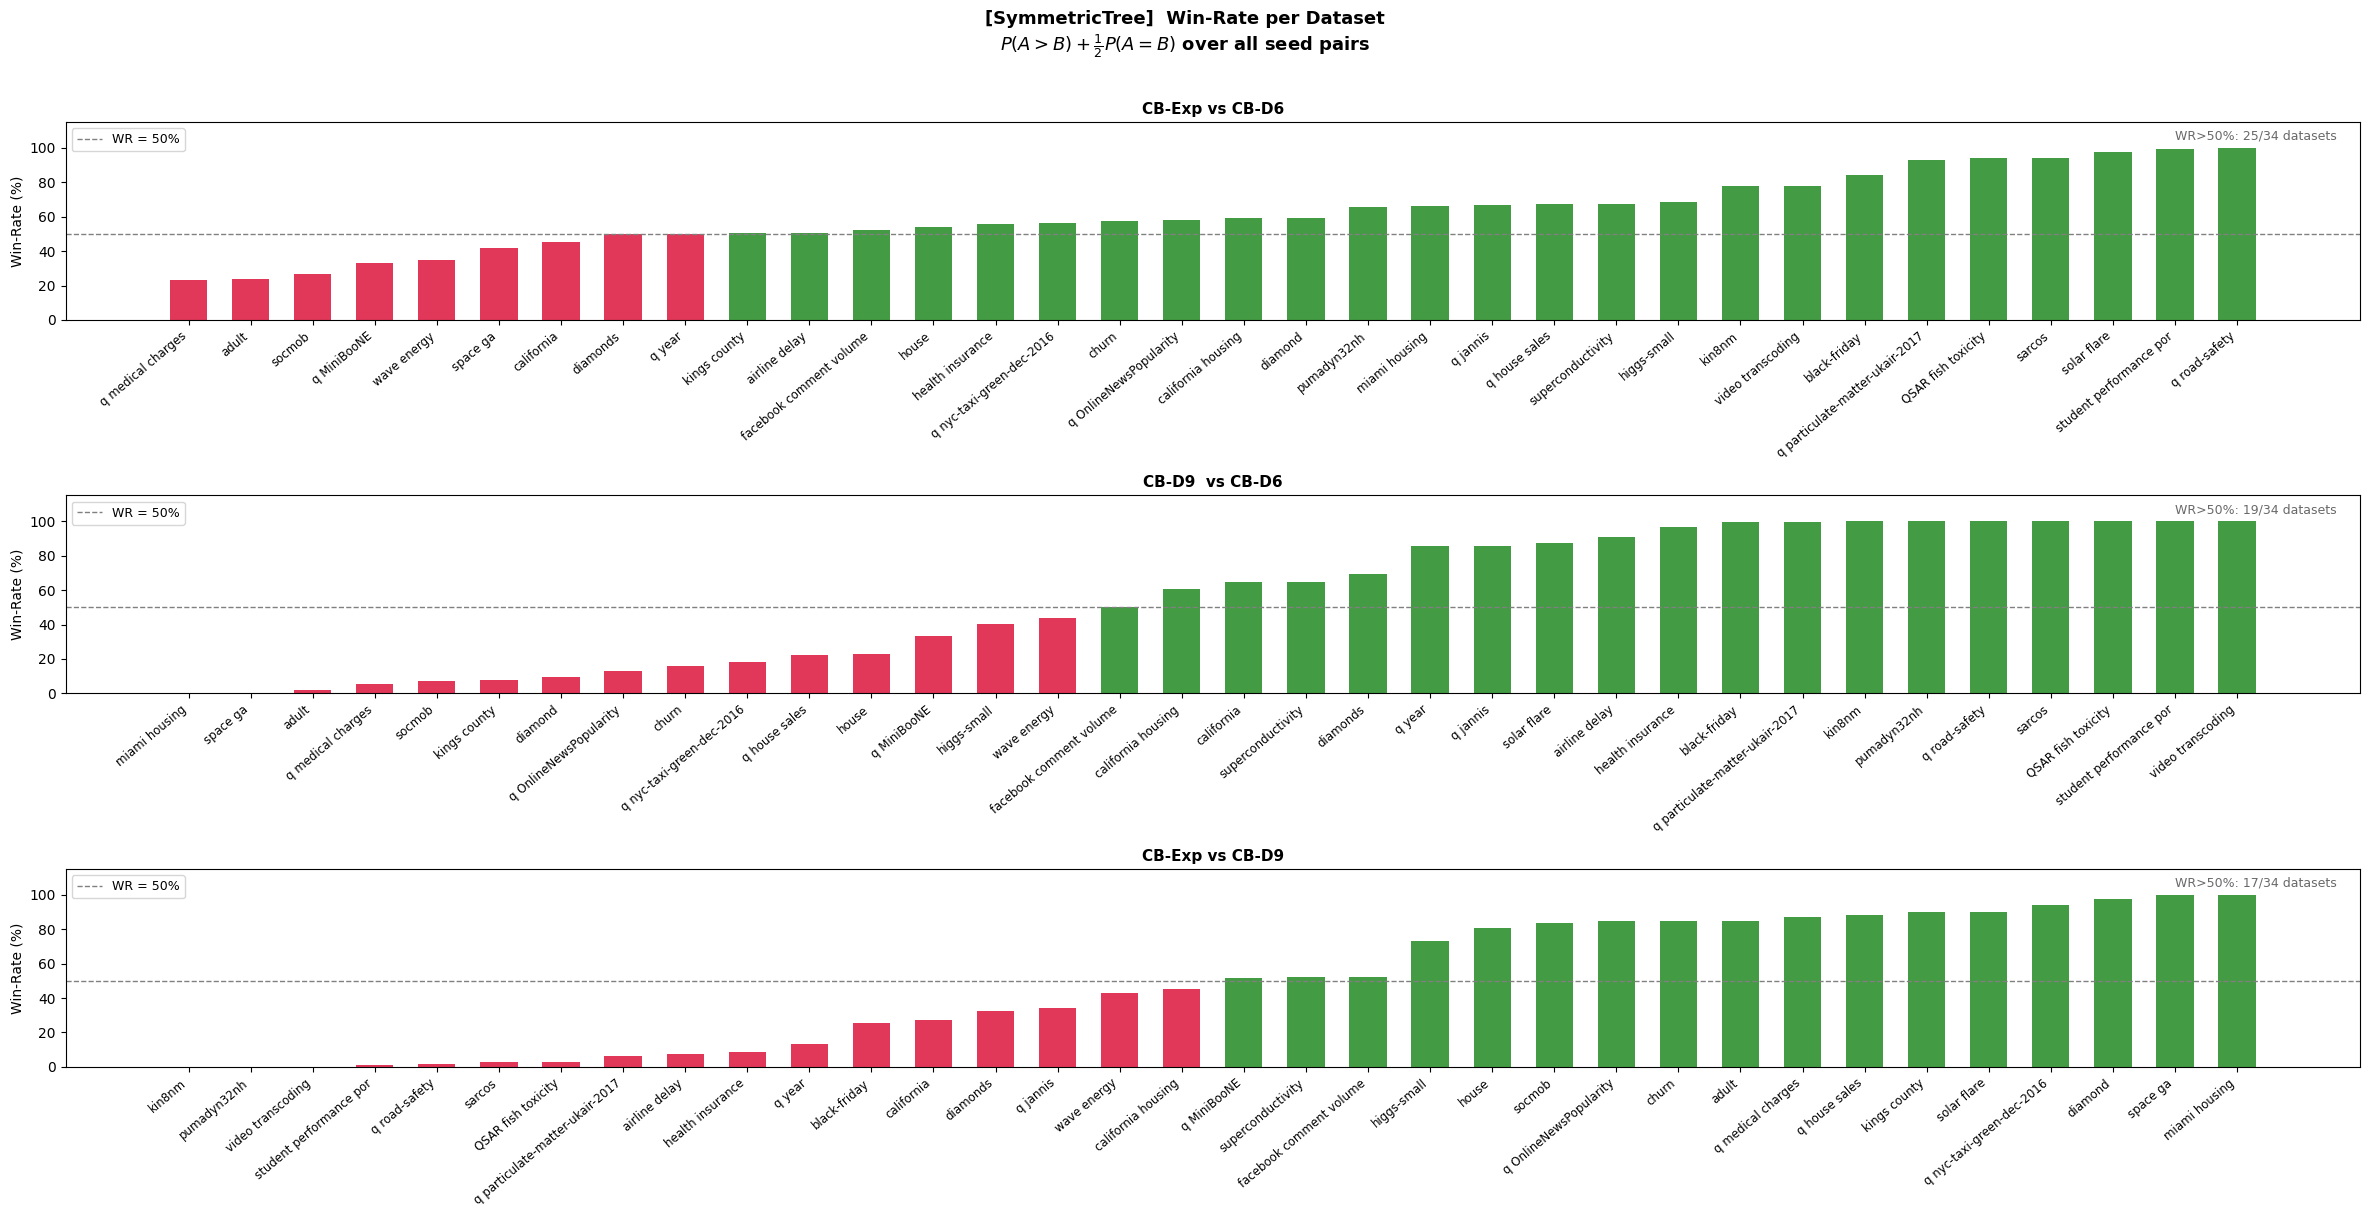

Figure 3 — 3-Way Ranking Heatmap  [SymmetricTree]...
✓ Saved: fig_ranking_heatmap_symmetrictree.pdf


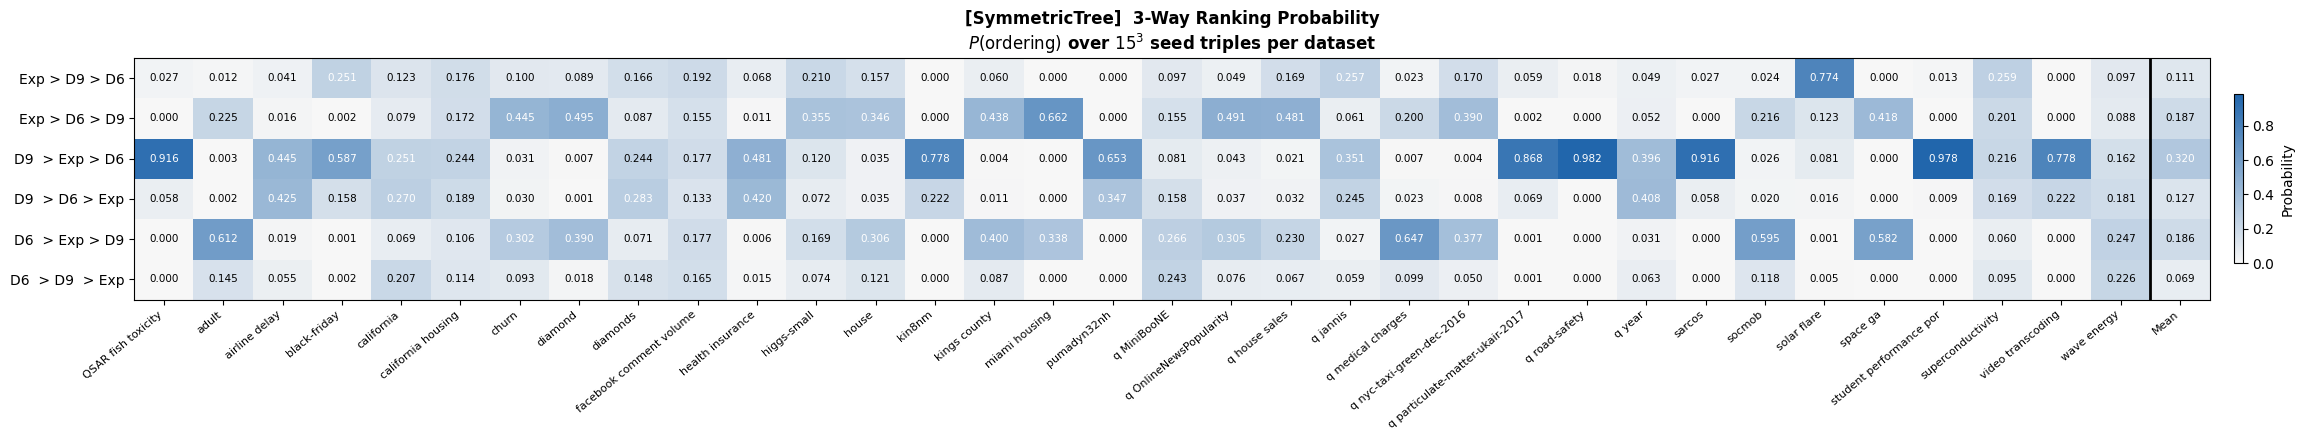

Figure 4 — Training Time Ratio  [SymmetricTree]...
✓ Saved: fig_time_ratio_symmetrictree.pdf


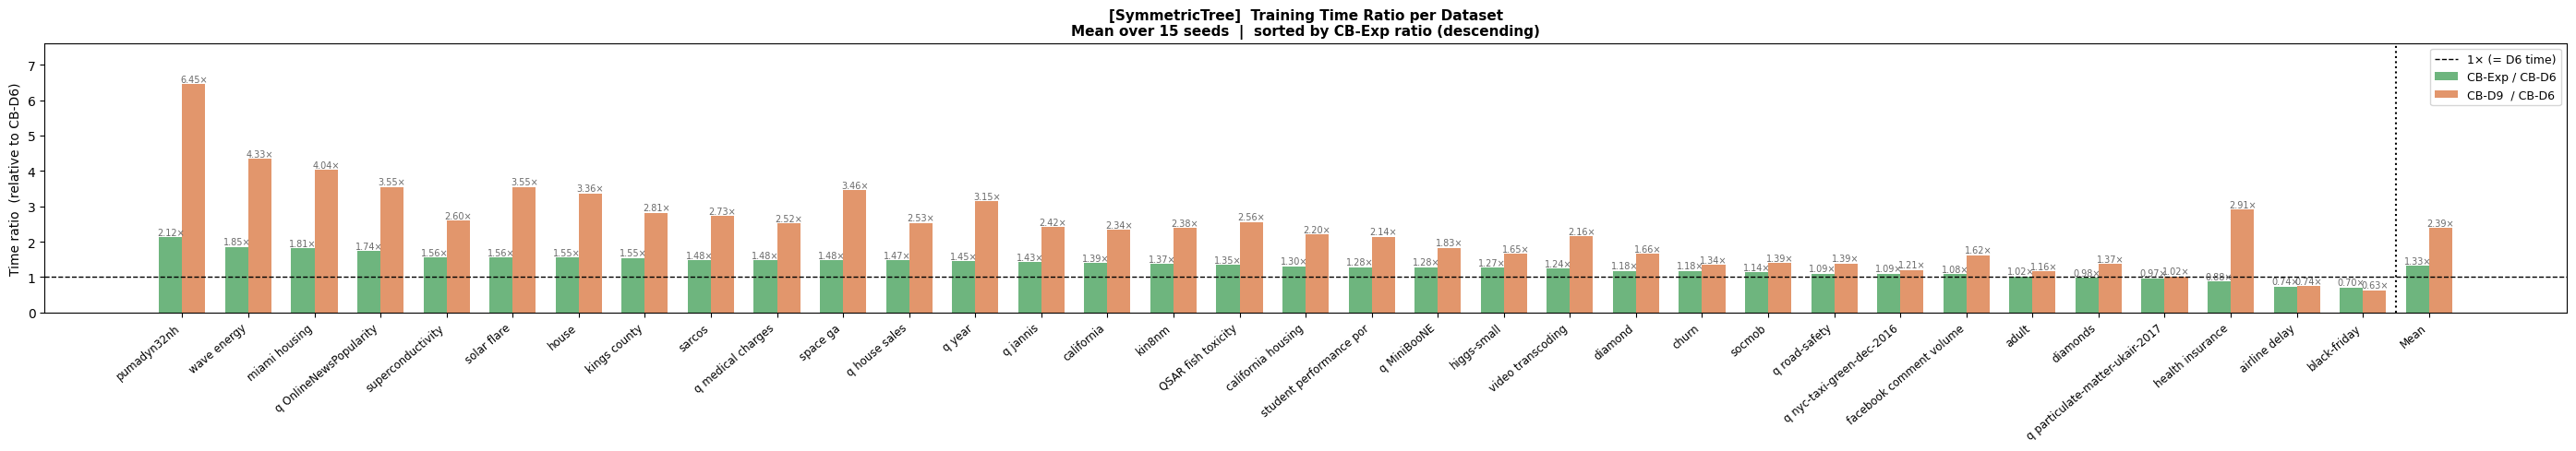

  Mean time ratio  CB-Exp / CB-D6 : 1.326×  (±0.306)
  Mean time ratio  CB-D9  / CB-D6 : 2.388×  (±1.162)

 DONE


In [1]:
"""
CatBoost Benchmark Analysis
===========================
Compares CB_Experimental and CB_Default_depth=9 against CB_Default (depth=6)
for both Depthwise and SymmetricTree grow policies.

CSV files are expected at:
  ../results/benchmark_results_depthwise.csv
  ../results/benchmark_results_symmtree.csv

Figures (generated for each grow policy independently)
-------------------------------------------------------
1. Improvability per dataset        — Exp vs D6, D9 vs D6, Exp vs D9
2. Win-rate per dataset             — Exp vs D6, D9 vs D6, Exp vs D9
3. 3-way ranking probability heatmap — all 6 orderings, per dataset + mean
4. Training time ratio              — Exp / D6 and D9 / D6, per dataset + mean
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from itertools import permutations

# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

RESULTS_DIR = Path("../results")

RUNS = {
    "Depthwise":    RESULTS_DIR / "01_benchmark_results_depthwise.csv",
    "SymmetricTree": RESULTS_DIR / "02_benchmark_results_symmtree.csv",
}

MODEL_EXP = "CB_Experimental"
MODEL_D9  = "CB_Default_depth=9"
MODEL_D6  = "CB_Default"

PAIRS = [
    (MODEL_EXP, MODEL_D6, "CB-Exp vs CB-D6"),
    (MODEL_D9,  MODEL_D6, "CB-D9  vs CB-D6"),
    (MODEL_EXP, MODEL_D9, "CB-Exp vs CB-D9"),
]

ORDERING_LABELS = [
    "Exp > D9 > D6",
    "Exp > D6 > D9",
    "D9  > Exp > D6",
    "D9  > D6 > Exp",
    "D6  > Exp > D9",
    "D6  > D9  > Exp",
]

# ══════════════════════════════════════════════════════════════════════════════
# LOAD & VALIDATE
# ══════════════════════════════════════════════════════════════════════════════

def load_data(path: Path) -> tuple[dict, dict, list[str]]:
    """
    Returns
    -------
    scores   : {model_name -> DataFrame[seed x dataset]}
    times    : {model_name -> DataFrame[seed x dataset]}
    datasets : list of dataset names with all 15 seeds present for all 3 models
    """
    df         = pd.read_csv(path)
    all_models = [MODEL_EXP, MODEL_D9, MODEL_D6]

    required_seeds = set(range(15))
    valid_ds = [
        ds for ds, grp in df.groupby("dataset")
        if all(
            set(grp[grp["variant"] == m]["seed"].values) >= required_seeds
            for m in all_models
        )
    ]

    df = df[df["dataset"].isin(valid_ds) & df["variant"].isin(all_models)]

    scores, times = {}, {}
    for m in all_models:
        sub       = df[df["variant"] == m].pivot(index="seed", columns="dataset", values="score")
        scores[m] = sub[valid_ds]
        sub_t     = df[df["variant"] == m].pivot(index="seed", columns="dataset", values="train_time_s")
        times[m]  = sub_t[valid_ds]

    print(f"  Complete datasets : {len(valid_ds)}")
    print(f"  Seeds per model   : {scores[MODEL_D6].shape[0]}")
    return scores, times, valid_ds

# ══════════════════════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════════════════════

def improvability(scores_a: np.ndarray, scores_ref: np.ndarray) -> float:
    a   = np.asarray(scores_a,   dtype=float)
    ref = np.asarray(scores_ref, dtype=float)
    return float((a.mean() - ref.mean()) / (abs(ref.mean()) + 1e-12))


def winrate(scores_a: np.ndarray, scores_b: np.ndarray) -> float:
    a, b = np.asarray(scores_a, dtype=float), np.asarray(scores_b, dtype=float)
    n    = len(a) * len(b)
    win  = sum(float(ai > bi) for ai in a for bi in b)
    tie  = sum(float(ai == bi) for ai in a for bi in b)
    return (win + 0.5 * tie) / n


_PERM_TO_IDX = {
    (0, 1, 2): 0,  # Exp > D9  > D6
    (0, 2, 1): 1,  # Exp > D6  > D9
    (1, 0, 2): 2,  # D9  > Exp > D6
    (1, 2, 0): 3,  # D9  > D6  > Exp
    (2, 0, 1): 4,  # D6  > Exp > D9
    (2, 1, 0): 5,  # D6  > D9  > Exp
}


def three_way_probs(s_exp, s_d9, s_d6) -> dict[str, float]:
    s_exp = np.asarray(s_exp, dtype=float)
    s_d9  = np.asarray(s_d9,  dtype=float)
    s_d6  = np.asarray(s_d6,  dtype=float)

    counts  = np.zeros(6, dtype=float)
    n_total = float(len(s_exp) * len(s_d9) * len(s_d6))

    for e in s_exp:
        for d9 in s_d9:
            for d6 in s_d6:
                t     = (e, d9, d6)
                valid = [p for p in permutations((0, 1, 2))
                         if t[p[0]] >= t[p[1]] >= t[p[2]]]
                if not valid:
                    continue
                w = 1.0 / len(valid)
                for p in valid:
                    counts[_PERM_TO_IDX[p]] += w

    probs = counts / n_total
    return {lbl: float(probs[i]) for i, lbl in enumerate(ORDERING_LABELS)}

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Improvability
# ══════════════════════════════════════════════════════════════════════════════

def plot_improvability(scores: dict, datasets: list[str], policy: str) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(max(12, len(datasets) * 0.7), 12),
                             sharex=False)
    fig.suptitle(
        f"[{policy}]  Improvability over Reference Model\n"
        r"$({\mu}_A - {\mu}_{ref}) \;/\; |{\mu}_{ref}|$",
        fontsize=13, fontweight="bold", y=1.01,
    )

    for ax, (model_a, model_b, title) in zip(axes, PAIRS):
        imp_vals = np.array([
            improvability(scores[model_a][ds].values, scores[model_b][ds].values) * 100
            for ds in datasets
        ])
        order      = np.argsort(imp_vals)
        sorted_ds  = [datasets[i] for i in order]
        sorted_imp = imp_vals[order]
        colors     = ["forestgreen" if v > 0 else "crimson" for v in sorted_imp]

        x = np.arange(len(sorted_ds))
        ax.bar(x, sorted_imp, color=colors, alpha=0.85, width=0.6)
        ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
        ax.set_xticks(x)
        ax.set_xticklabels([d.replace("_", " ") for d in sorted_ds],
                           rotation=40, ha="right", fontsize=8.5)
        ax.set_ylabel("Improvability (%)", fontsize=10)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.2f}%"))
        pos = (imp_vals > 0).sum()
        ax.text(0.99, 0.96, f"↑ {pos}/{len(datasets)} datasets",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, color="dimgray")

    plt.tight_layout()
    tag = policy.lower()
    plt.savefig(f"fig_improvability_{tag}.pdf", bbox_inches="tight")
    print(f"✓ Saved: fig_improvability_{tag}.pdf")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Win-Rate
# ══════════════════════════════════════════════════════════════════════════════

def plot_winrate(scores: dict, datasets: list[str], policy: str) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(max(12, len(datasets) * 0.7), 12),
                             sharex=False)
    fig.suptitle(
        f"[{policy}]  Win-Rate per Dataset\n"
        r"$P(A > B) + \frac{1}{2}P(A = B)$ over all seed pairs",
        fontsize=13, fontweight="bold", y=1.01,
    )

    for ax, (model_a, model_b, title) in zip(axes, PAIRS):
        wr_vals   = np.array([
            winrate(scores[model_a][ds].values, scores[model_b][ds].values)
            for ds in datasets
        ])
        order     = np.argsort(wr_vals)
        sorted_ds = [datasets[i] for i in order]
        sorted_wr = wr_vals[order] * 100

        colors = ["forestgreen" if v > 50 else ("gold" if v == 50 else "crimson")
                  for v in sorted_wr]

        x = np.arange(len(sorted_ds))
        ax.bar(x, sorted_wr, color=colors, alpha=0.85, width=0.6)
        ax.axhline(50, color="gray", linewidth=1.0, linestyle="--", label="WR = 50%")
        ax.set_xticks(x)
        ax.set_xticklabels([d.replace("_", " ") for d in sorted_ds],
                           rotation=40, ha="right", fontsize=8.5)
        ax.set_ylabel("Win-Rate (%)", fontsize=10)
        ax.set_ylim(0, 115)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.legend(fontsize=9, loc="upper left")
        wins = (wr_vals > 0.5).sum()
        ax.text(0.99, 0.96, f"WR>50%: {wins}/{len(datasets)} datasets",
                transform=ax.transAxes, ha="right", va="top",
                fontsize=9, color="dimgray")

    plt.tight_layout()
    tag = policy.lower()
    plt.savefig(f"fig_winrate_{tag}.pdf", bbox_inches="tight")
    print(f"✓ Saved: fig_winrate_{tag}.pdf")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — 3-Way Ranking Heatmap
# ══════════════════════════════════════════════════════════════════════════════

def plot_ranking_heatmap(scores: dict, datasets: list[str], policy: str) -> None:
    col_names = datasets + ["Mean"]
    matrix    = np.zeros((6, len(col_names)))

    for j, ds in enumerate(datasets):
        probs = three_way_probs(
            scores[MODEL_EXP][ds].values,
            scores[MODEL_D9][ds].values,
            scores[MODEL_D6][ds].values,
        )
        for i, lbl in enumerate(ORDERING_LABELS):
            matrix[i, j] = probs[lbl]

    matrix[:, -1] = matrix[:, :-1].mean(axis=1)

    fig, ax = plt.subplots(figsize=(max(14, len(col_names) * 0.75), 4.5))
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "wr", ["#f7f7f7", "#2166ac"], N=256)
    im = ax.imshow(matrix, cmap=cmap, vmin=0, aspect="auto")

    for i in range(6):
        for j in range(len(col_names)):
            val   = matrix[i, j]
            color = "white" if val > 0.25 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=7.5 if len(col_names) > 15 else 8.5, color=color)

    ax.axvline(len(datasets) - 0.5, color="black", lw=2)
    ax.set_xticks(range(len(col_names)))
    ax.set_xticklabels([d.replace("_", " ") for d in col_names],
                       rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(6))
    ax.set_yticklabels(ORDERING_LABELS, fontsize=10)
    cbar = fig.colorbar(im, ax=ax, shrink=0.7, pad=0.01)
    cbar.set_label("Probability", fontsize=10)
    ax.set_title(
        f"[{policy}]  3-Way Ranking Probability\n"
        r"$P(\text{ordering})$ over $15^3$ seed triples per dataset",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    tag = policy.lower()
    plt.savefig(f"fig_ranking_heatmap_{tag}.pdf", bbox_inches="tight")
    print(f"✓ Saved: fig_ranking_heatmap_{tag}.pdf")
    plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Training Time Ratio
# ══════════════════════════════════════════════════════════════════════════════

def plot_time_ratio(times: dict, datasets: list[str], policy: str) -> None:
    """
    Mean training time of Exp and D9 relative to D6, per dataset + mean bar.
    Sorted by Exp/D6 ratio descending.
    """
    t_exp = np.array([times[MODEL_EXP][ds].mean() for ds in datasets])
    t_d9  = np.array([times[MODEL_D9][ds].mean()  for ds in datasets])
    t_d6  = np.array([times[MODEL_D6][ds].mean()  for ds in datasets])

    ratio_exp = t_exp / (t_d6 + 1e-12)
    ratio_d9  = t_d9  / (t_d6 + 1e-12)

    order      = np.argsort(ratio_exp)[::-1]
    sorted_ds  = [datasets[i] for i in order] + ["Mean"]
    r_exp_plot = np.append(ratio_exp[order], ratio_exp.mean())
    r_d9_plot  = np.append(ratio_d9[order],  ratio_d9.mean())

    n, w = len(sorted_ds), 0.35
    x    = np.arange(n)

    fig, ax = plt.subplots(figsize=(max(13, n * 0.8), 5))

    bars_exp = ax.bar(x - w/2, r_exp_plot, width=w, color="#55A868",
                      alpha=0.85, label="CB-Exp / CB-D6")
    bars_d9  = ax.bar(x + w/2, r_d9_plot,  width=w, color="#DD8452",
                      alpha=0.85, label="CB-D9  / CB-D6")

    ax.axhline(1.0, color="black", linewidth=1.0, linestyle="--", label="1× (= D6 time)")
    ax.axvline(n - 1.5, color="black", lw=1.5, ls=":")

    for bar in list(bars_exp) + list(bars_d9):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f"{h:.2f}×", ha="center", va="bottom",
                fontsize=7 if n > 15 else 8, color="dimgray")

    ax.set_xticks(x)
    ax.set_xticklabels([d.replace("_", " ") for d in sorted_ds],
                       rotation=40, ha="right", fontsize=8.5)
    ax.set_ylabel("Time ratio  (relative to CB-D6)", fontsize=10)
    ax.set_title(
        f"[{policy}]  Training Time Ratio per Dataset\n"
        "Mean over 15 seeds  |  sorted by CB-Exp ratio (descending)",
        fontsize=11, fontweight="bold",
    )
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(r_exp_plot.max(), r_d9_plot.max()) * 1.18)

    plt.tight_layout()
    tag = policy.lower()
    plt.savefig(f"fig_time_ratio_{tag}.pdf", bbox_inches="tight")
    print(f"✓ Saved: fig_time_ratio_{tag}.pdf")
    plt.show()

    print(f"  Mean time ratio  CB-Exp / CB-D6 : {ratio_exp.mean():.3f}×"
          f"  (±{ratio_exp.std():.3f})")
    print(f"  Mean time ratio  CB-D9  / CB-D6 : {ratio_d9.mean():.3f}×"
          f"  (±{ratio_d9.std():.3f})")

# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ══════════════════════════════════════════════════════════════════════════════

def print_summary(scores: dict, datasets: list[str], policy: str) -> None:
    print("\n" + "=" * 70)
    print(f" SUMMARY TABLE  [{policy}]")
    print("=" * 70)
    rows = []
    for model_a, model_b, label in PAIRS:
        imp_vals = [
            improvability(scores[model_a][ds].values, scores[model_b][ds].values) * 100
            for ds in datasets
        ]
        wr_vals = [
            winrate(scores[model_a][ds].values, scores[model_b][ds].values)
            for ds in datasets
        ]
        rows.append({
            "Comparison":              label,
            "Mean Improvability    ":  f"{np.mean(imp_vals):+.3f}%",
            "Std  Improvability    ":  f"{np.std(imp_vals):.3f}%",
            "WR > 50% datasets     ":  (
                f"{sum(w > 0.5 for w in wr_vals) + sum(w == 0.5 for w in wr_vals) / 2}"
                f"/{len(datasets)}"
            ),
            "Mean WR               ":  f"{np.mean(wr_vals) * 100:.1f}%",
        })
    tbl = pd.DataFrame(rows).set_index("Comparison")
    print(tbl.to_string())
    print("=" * 70)

# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    for policy, csv_path in RUNS.items():
        print("\n" + "=" * 70)
        print(f" {policy.upper()}")
        print("=" * 70)

        if not csv_path.exists():
            print(f"  ⚠  CSV not found: {csv_path} — skipping.")
            continue

        scores, times, datasets = load_data(csv_path)

        print_summary(scores, datasets, policy)

        print(f"\nFigure 1 — Improvability  [{policy}]...")
        plot_improvability(scores, datasets, policy)

        print(f"Figure 2 — Win-Rate  [{policy}]...")
        plot_winrate(scores, datasets, policy)

        print(f"Figure 3 — 3-Way Ranking Heatmap  [{policy}]...")
        plot_ranking_heatmap(scores, datasets, policy)

        print(f"Figure 4 — Training Time Ratio  [{policy}]...")
        plot_time_ratio(times, datasets, policy)

    print("\n" + "=" * 70)
    print(" DONE")
    print("=" * 70)